Configuring GPU settings...
✓ GPU found: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

                      MOBILENET-UNET WITH UPERNET DECODER (MSCA + LBFR + PPM)                       
Loading train data...
  train: 400 samples
Loading val data...
  val: 400 samples
Loading test data...
  test: 400 samples
Split - Train: 600, Val: 200, Test: 400

TRAINING: UPerNet_Focal_MC
  Loss: Focal + EIoU
  Architecture: UPerNet Decoder + MC Dropout
  Bridge: PPM (Pyramid Pooling Module)
  Decoder: MSCA + LBFR per block
  Enhancement: Full ODFormer decoder architecture

Model Configuration:
  Total Parameters: 45,241,803
  Dropout Layers: 9
  Architecture: UPerNet Decoder
  Bridge: PPM (Pyramid Pooling Module)
  Decoder: 4× UPerNet blocks with MSCA + LBFR
  MSCA: Multi-scale Context Aggregator (dilation rates: 1,2,3,5)
  LBFR: Lightweight Bidirectional Feature Recalibrator
  PPM Scales: [1×1, 2×2, 3×3, 6×6]
  Enhancement: Full ODFormer decoder architecture
Epoch 1/50


I0000 00:00:1763462583.895651     113 service.cc:148] XLA service 0x7b999c004e60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1763462583.896586     113 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1763462591.068323     113 cuda_dnn.cc:529] Loaded cuDNN version 90300


  1/150 ━━━━━━━━━━━━━━━━━━━━ 4:29:50 109s/step - accuracy: 0.2553 - dice_class_0: 0.4061 - dice_class_1: 0.0033 - dice_class_2: 0.0134 - dice_coef_multiclass: 0.2999 - iou_class_0: 0.2548 - iou_class_1: 0.0017 - iou_class_2: 0.0067 - iou_coef_multiclass: 0.1764 - loss: 1.7267

I0000 00:00:1763462640.866397     113 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.8122 - dice_class_0: 0.8812 - dice_class_1: 0.2487 - dice_class_2: 0.1654 - dice_coef_multiclass: 0.5328 - iou_class_0: 0.8130 - iou_class_1: 0.1524 - iou_class_2: 0.0960 - iou_coef_multiclass: 0.3717 - loss: 1.2471
Epoch 1: val_loss improved from inf to 0.78718, saving model to results/UPerNet_Focal_MC.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 144s 237ms/step - accuracy: 0.8129 - dice_class_0: 0.8817 - dice_class_1: 0.2497 - dice_class_2: 0.1660 - dice_coef_multiclass: 0.5336 - iou_class_0: 0.8137 - iou_class_1: 0.1532 - iou_class_2: 0.0964 - iou_coef_multiclass: 0.3724 - loss: 1.2460 - val_accuracy: 0.9617 - val_dice_class_0: 0.9830 - val_dice_class_1: 0.5570 - val_dice_class_2: 0.1544 - val_dice_coef_multiclass: 0.8521 - val_iou_class_0: 0.9666 - val_iou_class_1: 0.3877 - val_iou_class_2: 0.0841 - val_iou_coef_multiclass: 0.7424 - val_loss: 0.7872 - learning_rate: 5.0000e-04
Epoch 2/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - acc

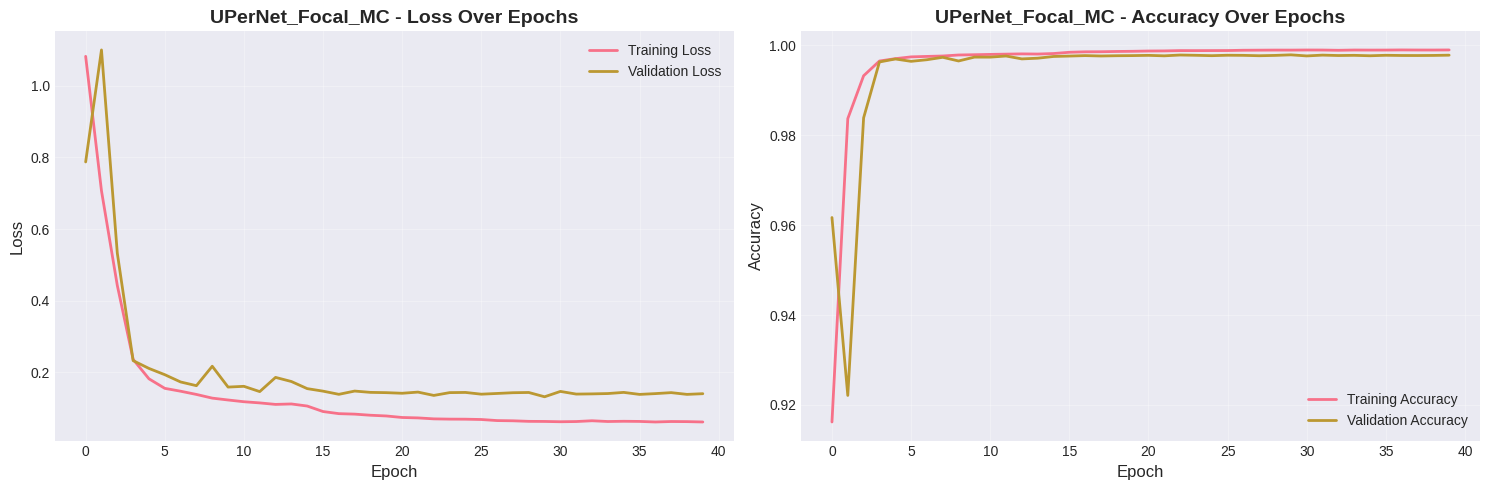

  ✓ Saved: results/UPerNet_Focal_MC_history.png


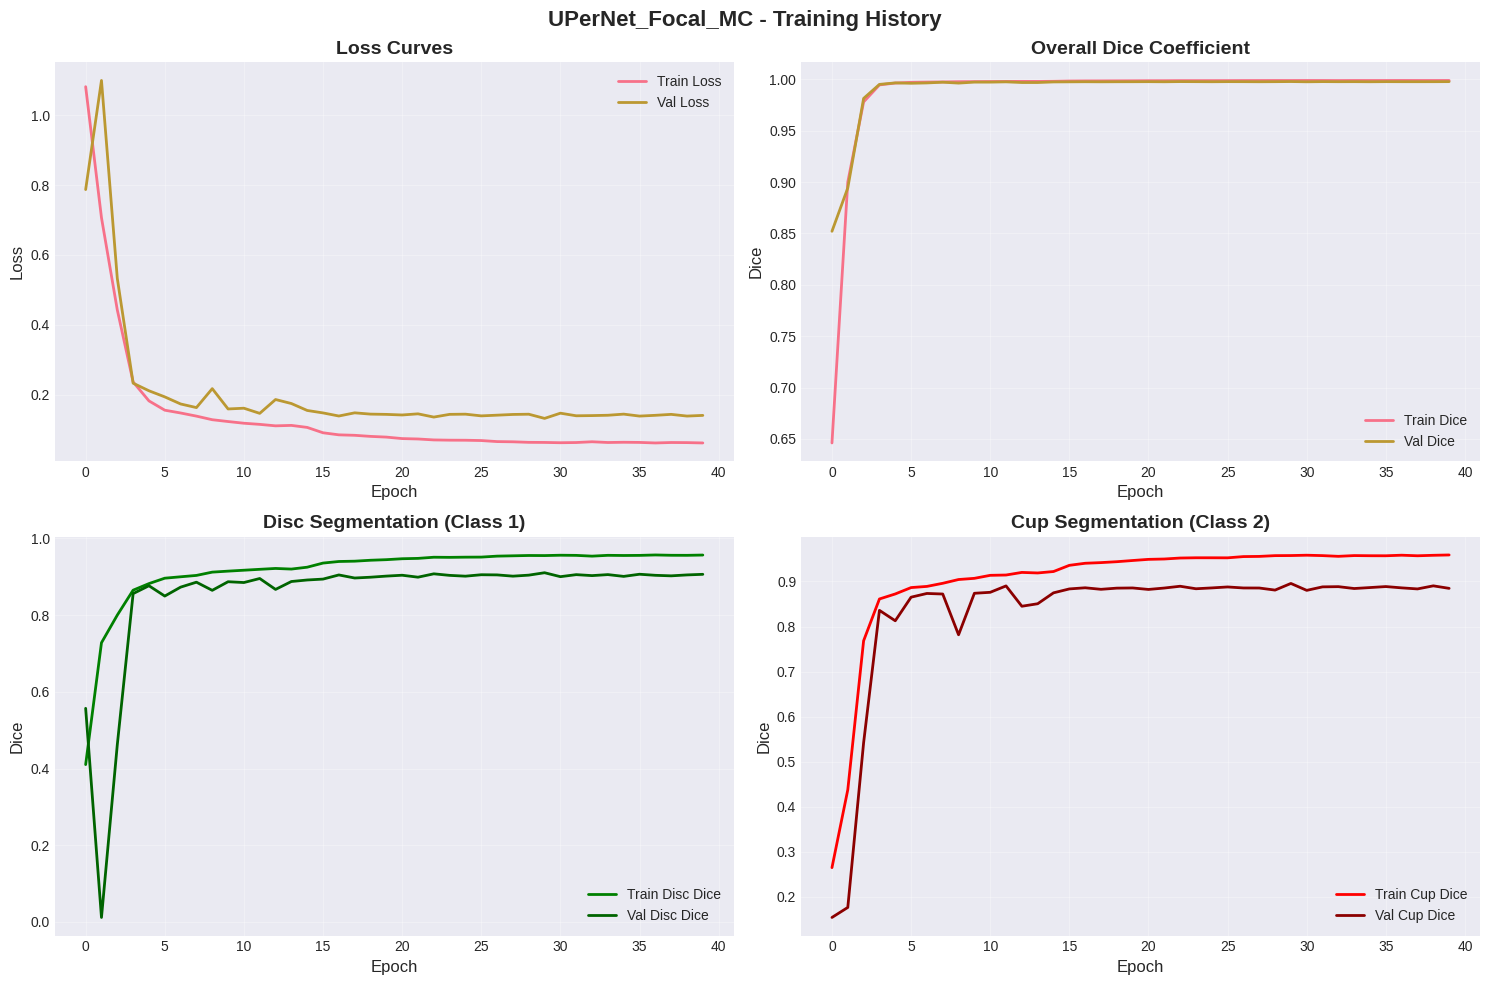

  ✓ Saved: results/UPerNet_Focal_MC_predictions.png


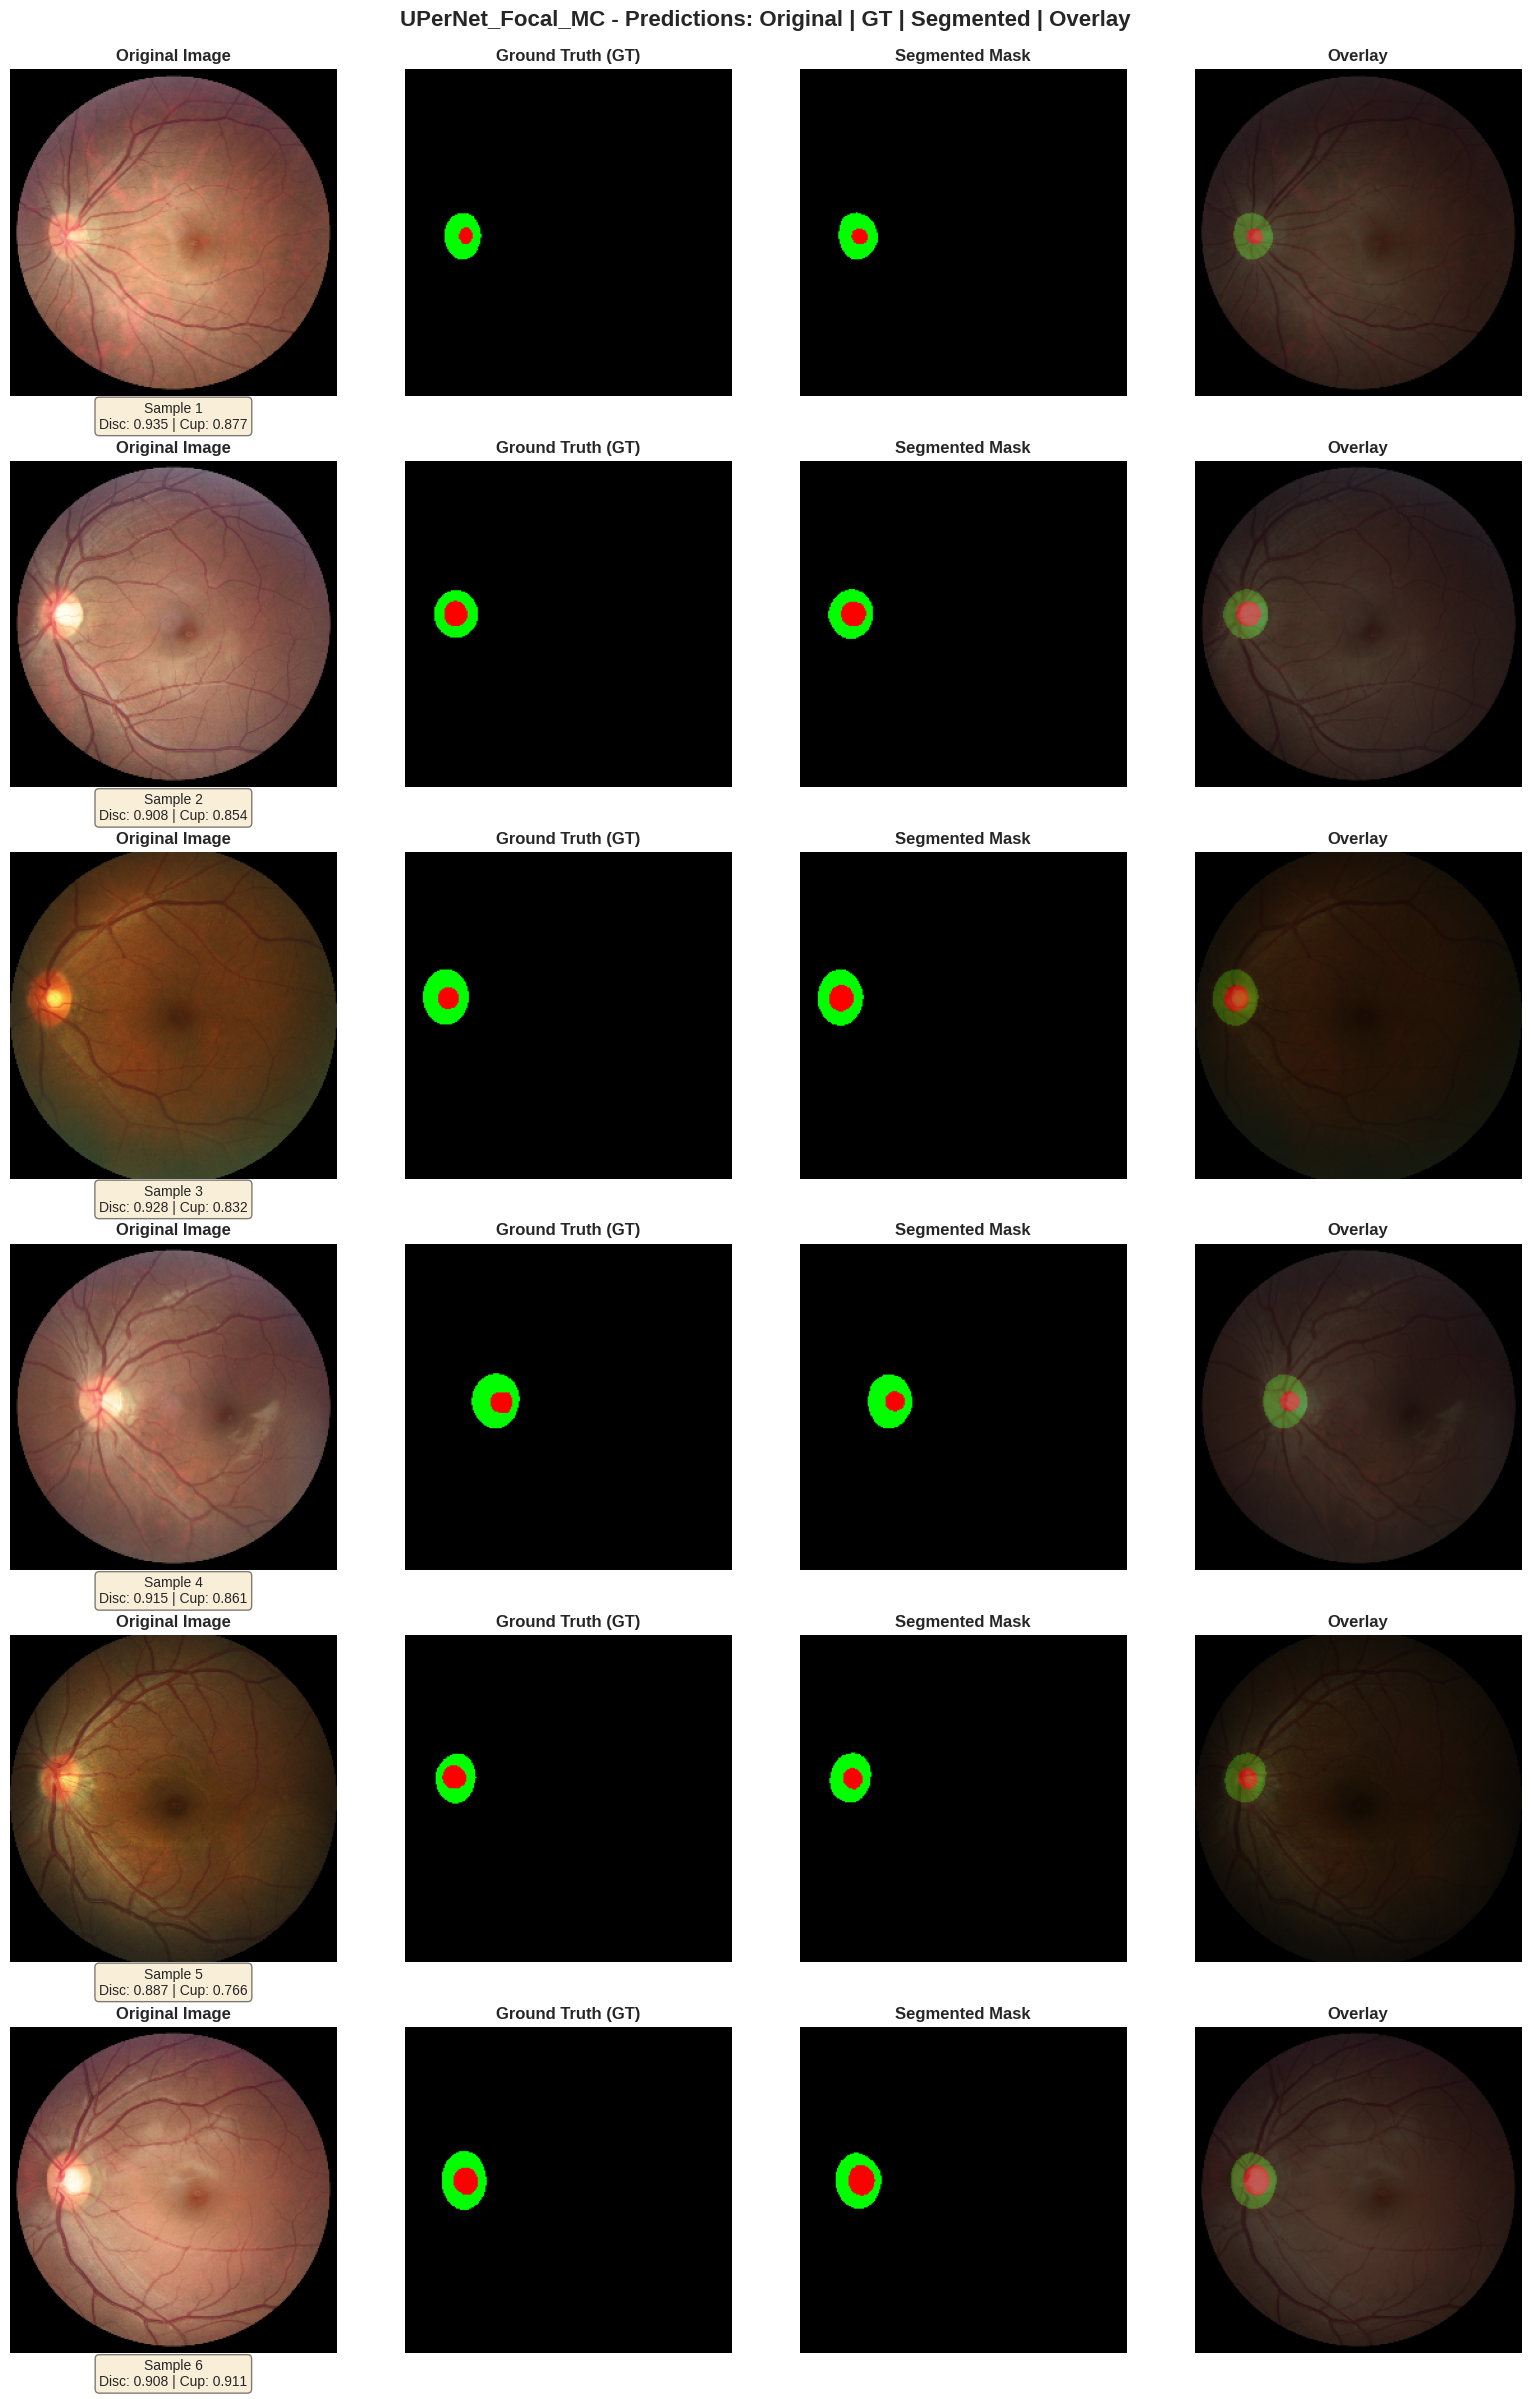


EVALUATION: UPerNet+Focal+MC
  ✓ Saved: results/UPerNet+Focal+MC_confusion_matrices.png


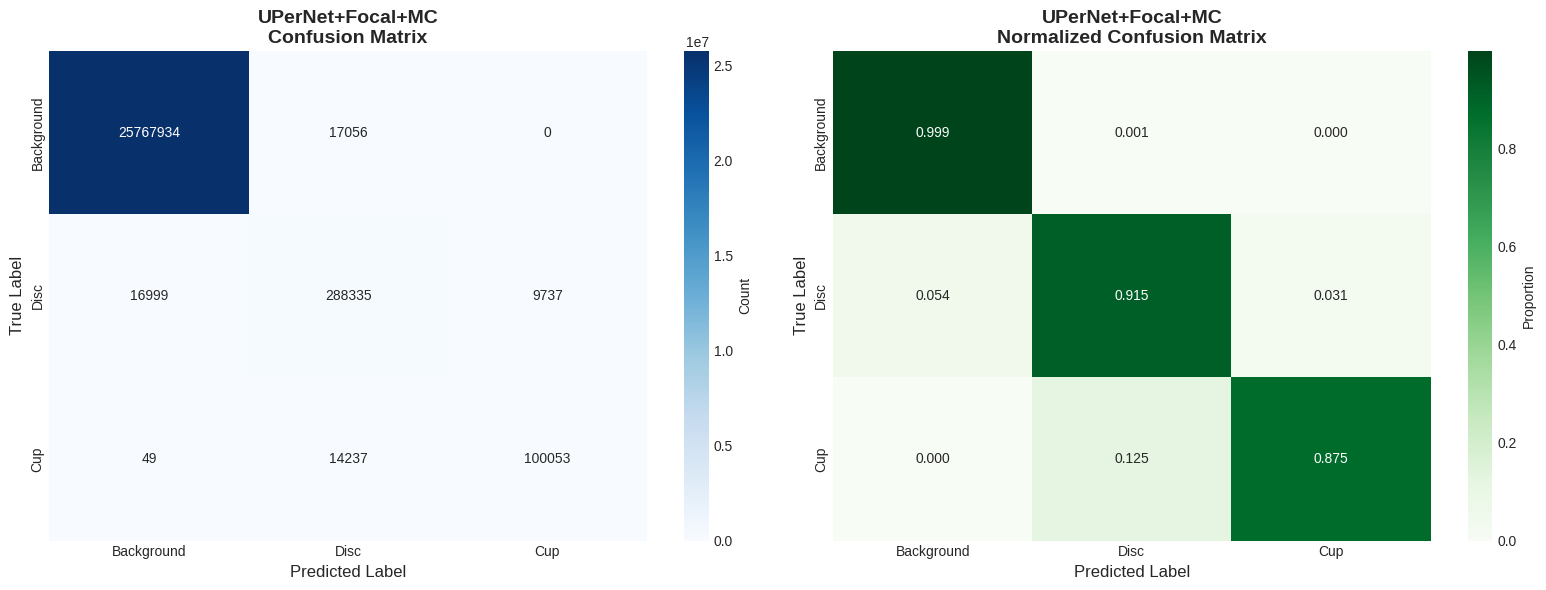


Confusion Matrix:
[[25767934    17056        0]
 [   16999   288335     9737]
 [      49    14237   100053]]

Normalized Confusion Matrix:
[[0.999 0.001 0.   ]
 [0.054 0.915 0.031]
 [0.    0.125 0.875]]

Precision, Recall, F1 Score per class:
  Background: Precision=0.9993, Recall=0.9993, F1=0.9993
  Disc: Precision=0.9021, Recall=0.9151, F1=0.9086
  Cup: Precision=0.9113, Recall=0.8751, F1=0.8928

Macro-averaged metrics:
  Precision: 0.9376
  Recall: 0.9298
  F1 Score: 0.9336
  Background: Dice=0.9993, IoU=0.9987
  Disc: Dice=0.9086, IoU=0.8325
  Cup: Dice=0.8928, IoU=0.8064

MC Dropout Evaluation:

Running MC Dropout with 10 stochastic forward passes...
  Completed: 5/10 forward passes
  Completed: 10/10 forward passes
✓ MC Dropout completed
  Background uncertainty: 0.0002
  Disc uncertainty: 0.0002
  Cup uncertainty: 0.0001

                                ✓ TRAINING AND EVALUATION COMPLETED!                                

Model: MobileNetV2 + UPerNet Decoder + Focal + EIoU + MC

In [3]:
"""
MOBILENET-UNET WITH UPERNET DECODER (MSCA + LBFR + PPM)
========================================================
Full UPerNet decoder architecture from ODFormer with all attention modules

UPerNet Decoder:
- PPM (Pyramid Pooling Module) for global context at bridge
- MSCA (Multi-scale Context Aggregator) for multi-scale features
- LBFR (Lightweight Bidirectional Feature Recalibrator) for attention
- FPN-style lateral connections
- From UPerNet architecture, enhanced with ODFormer modules

Configuration:
- Base: MobileNetV2 backbone + Focal-EIoU + MC Dropout
- Enhancement: Full UPerNet decoder with PPM + MSCA + LBFR
- Decoder: UPerNet blocks replacing standard deeper blocks
"""

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, backend as K
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import albumentations as A
import warnings
import gc
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ============================================================================
# GPU CONFIGURATION
# ============================================================================

def configure_gpu():
    """Configure GPU settings for optimal performance"""
    print("Configuring GPU settings...")
    physical_devices = tf.config.list_physical_devices('GPU')
    if physical_devices:
        try:
            for gpu in physical_devices:
                tf.config.experimental.set_memory_growth(gpu, True)
            tf.config.set_visible_devices(physical_devices[0], 'GPU')
            print(f"✓ GPU found: {physical_devices}")
            return True
        except RuntimeError as e:
            print(f"✗ GPU configuration error: {e}")
            return False
    else:
        print("✗ No GPU found, using CPU")
        return False

# ============================================================================
# DATA LOADING
# ============================================================================

def load_images_masks(images_folder, masks_folder, img_size=(256,256)):
    """Load images and masks from folders"""
    images, masks = [], []
    image_files = sorted(os.listdir(images_folder))
    mask_files = sorted(os.listdir(masks_folder))
    mask_dict = {os.path.splitext(f)[0]: f for f in mask_files}
    
    for img_file in image_files:
        base = os.path.splitext(img_file)[0]
        if base in mask_dict:
            img = cv2.imread(os.path.join(images_folder, img_file))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, img_size) / 255.0
            
            mask = cv2.imread(os.path.join(masks_folder, mask_dict[base]), cv2.IMREAD_GRAYSCALE)
            mask = cv2.resize(mask, img_size)
            unique_vals = np.unique(mask)
            if len(unique_vals) > 3 or np.max(unique_vals) > 2:
                mask = np.clip(mask // 85, 0, 2).astype(np.uint8)
            
            images.append(img)
            masks.append(mask)
    
    return np.array(images, dtype=np.float32), np.array(masks, dtype=np.uint8)

def load_all_data(root_dir):
    """Load all data from existing splits and merge"""
    all_images, all_masks = [], []
    for split in ["train", "val", "test"]:
        print(f"Loading {split} data...")
        imgs, msks = load_images_masks(
            os.path.join(root_dir, split, "Images"),
            os.path.join(root_dir, split, "Masks")
        )
        all_images.append(imgs)
        all_masks.append(msks)
        print(f"  {split}: {imgs.shape[0]} samples")
    
    all_images = np.concatenate(all_images, axis=0)
    all_masks = np.concatenate(all_masks, axis=0)
    return all_images, all_masks

def create_new_split(all_images, all_masks):
    """Create new split: 600 train, 200 val, 400 test"""
    X_temp, X_test, y_temp, y_test = train_test_split(
        all_images, all_masks, test_size=400, random_state=42
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=200, random_state=42
    )
    print(f"Split - Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")
    return (X_train, y_train), (X_val, y_val), (X_test, y_test)

# ============================================================================
# DATA AUGMENTATION
# ============================================================================

def setup_augmentations():
    return A.Compose([
        A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.7),
        A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=15, val_shift_limit=10, p=0.5),
        A.GaussianBlur(blur_limit=3, p=0.3),
        A.RandomGamma(gamma_limit=(80, 120), p=0.3),
    ])

def data_generator(images, masks, batch_size, augment=None):
    idxs = np.arange(len(images))
    while True:
        np.random.shuffle(idxs)
        for i in range(0, len(images), batch_size):
            batch_idxs = idxs[i:i+batch_size]
            batch_x, batch_y = [], []
            
            for idx in batch_idxs:
                img, mask = images[idx], masks[idx]
                
                if augment:
                    aug = augment(image=img, mask=mask)
                    img_aug, mask_aug = aug['image'], aug['mask']
                else:
                    img_aug, mask_aug = img, mask
                
                mask_cat = to_categorical(mask_aug, num_classes=3)
                batch_x.append(img_aug)
                batch_y.append(mask_cat)
            
            yield np.stack(batch_x).astype(np.float32), np.stack(batch_y).astype(np.float32)

# ============================================================================
# MSCA MODULE (FROM ODFORMER)
# ============================================================================

def msca_block(x, channels, dilation_rates=[1, 2, 3, 5], block_name='msca'):
    """Multi-scale Context Aggregator with dilated convolutions"""
    multi_scale_features = []
    filters_per_branch = channels // len(dilation_rates)
    
    for i, rate in enumerate(dilation_rates):
        branch = layers.Conv2D(
            filters_per_branch, 
            (3, 3), 
            padding='same',
            dilation_rate=rate,
            use_bias=False,
            name=f'{block_name}_conv_d{rate}'
        )(x)
        branch = layers.BatchNormalization(name=f'{block_name}_bn_d{rate}')(branch)
        branch = layers.Activation('relu', name=f'{block_name}_relu_d{rate}')(branch)
        multi_scale_features.append(branch)
    
    concat = layers.Concatenate(name=f'{block_name}_concat')(multi_scale_features)
    fused = layers.Conv2D(channels, (1, 1), use_bias=False, name=f'{block_name}_fusion')(concat)
    fused = layers.BatchNormalization(name=f'{block_name}_fusion_bn')(fused)
    fused = layers.Activation('relu', name=f'{block_name}_fusion_relu')(fused)
    
    output = layers.Add(name=f'{block_name}_residual')([x, fused])
    return output

# ============================================================================
# LBFR MODULE (FROM ODFORMER)
# ============================================================================

def lbfr_block(x, channels, reduction=16, block_name='lbfr'):
    """Lightweight Bidirectional Feature Recalibrator"""
    # Channel Attention
    avg_pool = layers.GlobalAveragePooling2D(name=f'{block_name}_avg_pool')(x)
    avg_pool = layers.Reshape((1, 1, channels), name=f'{block_name}_avg_reshape')(avg_pool)
    
    max_pool = layers.GlobalMaxPooling2D(name=f'{block_name}_max_pool')(x)
    max_pool = layers.Reshape((1, 1, channels), name=f'{block_name}_max_reshape')(max_pool)
    
    fc1 = layers.Conv2D(channels // reduction, (1, 1), use_bias=False, name=f'{block_name}_fc1')
    fc2 = layers.Conv2D(channels, (1, 1), use_bias=False, name=f'{block_name}_fc2')
    
    avg_out = fc1(avg_pool)
    avg_out = layers.Activation('relu', name=f'{block_name}_fc1_relu_avg')(avg_out)
    avg_out = fc2(avg_out)
    
    max_out = fc1(max_pool)
    max_out = layers.Activation('relu', name=f'{block_name}_fc1_relu_max')(max_out)
    max_out = fc2(max_out)
    
    channel_att = layers.Add(name=f'{block_name}_channel_add')([avg_out, max_out])
    channel_att = layers.Activation('sigmoid', name=f'{block_name}_channel_sigmoid')(channel_att)
    x_channel = layers.Multiply(name=f'{block_name}_channel_multiply')([x, channel_att])
    
    # Spatial Attention
    avg_spatial = layers.Lambda(lambda x: K.mean(x, axis=-1, keepdims=True), 
                                name=f'{block_name}_spatial_avg')(x_channel)
    max_spatial = layers.Lambda(lambda x: K.max(x, axis=-1, keepdims=True),
                                name=f'{block_name}_spatial_max')(x_channel)
    
    spatial_concat = layers.Concatenate(name=f'{block_name}_spatial_concat')([avg_spatial, max_spatial])
    spatial_att = layers.Conv2D(1, (7, 7), padding='same', use_bias=False,
                                name=f'{block_name}_spatial_conv')(spatial_concat)
    spatial_att = layers.Activation('sigmoid', name=f'{block_name}_spatial_sigmoid')(spatial_att)
    x_spatial = layers.Multiply(name=f'{block_name}_spatial_multiply')([x_channel, spatial_att])
    
    # Recalibration
    recalibrated = layers.Conv2D(channels, (1, 1), use_bias=False, 
                                 name=f'{block_name}_recalibrate')(x_spatial)
    recalibrated = layers.BatchNormalization(name=f'{block_name}_recalibrate_bn')(recalibrated)
    
    output = layers.Add(name=f'{block_name}_residual')([x, recalibrated])
    return output

# ============================================================================
# PPM MODULE (FROM PSPNET/ODFORMER)
# ============================================================================

def ppm_block(x, channels, pool_scales=[1, 2, 3, 6], block_name='ppm'):
    """Pyramid Pooling Module for multi-scale global context"""
    h, w = x.shape[1], x.shape[2]
    ppm_features = [x]
    filters_per_scale = channels // len(pool_scales)
    
    for i, scale in enumerate(pool_scales):
        pooled = layers.AveragePooling2D(
            pool_size=(h // scale, w // scale),
            strides=(h // scale, w // scale),
            name=f'{block_name}_pool_{scale}x{scale}'
        )(x)
        
        conv = layers.Conv2D(
            filters_per_scale,
            (1, 1),
            use_bias=False,
            name=f'{block_name}_conv_{scale}x{scale}'
        )(pooled)
        conv = layers.BatchNormalization(name=f'{block_name}_bn_{scale}x{scale}')(conv)
        conv = layers.Activation('relu', name=f'{block_name}_relu_{scale}x{scale}')(conv)
        
        upsampled = layers.UpSampling2D(
            size=(h // scale, w // scale),
            interpolation='bilinear',
            name=f'{block_name}_upsample_{scale}x{scale}'
        )(conv)
        
        ppm_features.append(upsampled)
    
    concat = layers.Concatenate(name=f'{block_name}_concat')(ppm_features)
    fused = layers.Conv2D(
        channels,
        (3, 3),
        padding='same',
        use_bias=False,
        name=f'{block_name}_fusion'
    )(concat)
    fused = layers.BatchNormalization(name=f'{block_name}_fusion_bn')(fused)
    fused = layers.Activation('relu', name=f'{block_name}_fusion_relu')(fused)
    
    return fused

# ============================================================================
# LOSS FUNCTIONS
# ============================================================================

def focal_loss(y_true, y_pred, gamma=2.0, alpha=None, epsilon=1e-7):
    if alpha is None:
        alpha = [0.25, 1.0, 1.0]
    
    y_pred = K.clip(y_pred, epsilon, 1.0 - epsilon)
    focal_loss_value = 0.0
    
    for c in range(3):
        y_true_c = y_true[:, :, :, c]
        y_pred_c = y_pred[:, :, :, c]
        pt = y_pred_c
        focal_weight = K.pow(1.0 - pt, gamma)
        cross_entropy = -K.log(pt)
        focal_loss_c = alpha[c] * focal_weight * cross_entropy * y_true_c
        focal_loss_value += K.mean(focal_loss_c)
    
    return focal_loss_value

def enhanced_iou_loss(y_true, y_pred, smooth=1e-7):
    eiou_loss_value = 0.0
    
    for c in range(3):
        y_true_c = y_true[:, :, :, c]
        y_pred_c = y_pred[:, :, :, c]
        
        intersection = K.sum(y_true_c * y_pred_c, axis=[1, 2])
        union = K.sum(y_true_c, axis=[1, 2]) + K.sum(y_pred_c, axis=[1, 2]) - intersection
        iou = (intersection + smooth) / (union + smooth)
        
        height = K.cast(K.shape(y_true_c)[1], 'float32')
        width = K.cast(K.shape(y_true_c)[2], 'float32')
        
        y_coords = K.arange(0, height)
        x_coords = K.arange(0, width)
        y_grid = K.tile(K.reshape(y_coords, (-1, 1)), (1, K.cast(width, 'int32')))
        x_grid = K.tile(K.reshape(x_coords, (1, -1)), (K.cast(height, 'int32'), 1))
        y_grid = K.cast(y_grid, 'float32')
        x_grid = K.cast(x_grid, 'float32')
        
        true_mass = K.sum(y_true_c, axis=[1, 2]) + smooth
        true_center_y = K.sum(y_true_c * y_grid, axis=[1, 2]) / true_mass
        true_center_x = K.sum(y_true_c * x_grid, axis=[1, 2]) / true_mass
        
        pred_mass = K.sum(y_pred_c, axis=[1, 2]) + smooth
        pred_center_y = K.sum(y_pred_c * y_grid, axis=[1, 2]) / pred_mass
        pred_center_x = K.sum(y_pred_c * x_grid, axis=[1, 2]) / pred_mass
        
        center_distance = K.square(true_center_y - pred_center_y) + K.square(true_center_x - pred_center_x)
        diagonal = K.square(height) + K.square(width)
        center_penalty = center_distance / (diagonal + smooth)
        
        true_width = K.sqrt(K.sum(K.sum(y_true_c, axis=1), axis=1) + smooth)
        true_height = K.sqrt(K.sum(K.sum(y_true_c, axis=2), axis=1) + smooth)
        pred_width = K.sqrt(K.sum(K.sum(y_pred_c, axis=1), axis=1) + smooth)
        pred_height = K.sqrt(K.sum(K.sum(y_pred_c, axis=2), axis=1) + smooth)
        
        width_diff = K.square(pred_width - true_width)
        height_diff = K.square(pred_height - true_height)
        aspect_penalty = width_diff / (K.square(width) + smooth) + height_diff / (K.square(height) + smooth)
        
        eiou_c = 1.0 - iou + center_penalty + aspect_penalty
        eiou_loss_value += K.mean(eiou_c)
    
    return eiou_loss_value / 3.0

def focal_eiou_combined_loss(y_true, y_pred, focal_weight=1.0, eiou_weight=1.0, gamma=2.0, alpha=None):
    fl = focal_loss(y_true, y_pred, gamma=gamma, alpha=alpha)
    eiou = enhanced_iou_loss(y_true, y_pred)
    return focal_weight * fl + eiou_weight * eiou

# ============================================================================
# UPERNET DECODER BLOCK (FULL ODFORMER ARCHITECTURE)
# ============================================================================

def upernet_decoder_block(x, skip_connection, filters, block_name, dropout_rate=0.3):
    """
    UPerNet decoder block with full ODFormer enhancements
    
    Features:
    - FPN-style lateral connections
    - MSCA for multi-scale context aggregation
    - LBFR for bidirectional feature recalibration
    - Residual connections
    - MC Dropout for uncertainty estimation
    """
    # Upsample
    x = layers.UpSampling2D((2, 2), interpolation='bilinear', name=f'{block_name}_upsample')(x)
    
    # Project upsampled features to target filters
    x = layers.Conv2D(filters, (1, 1), use_bias=False, name=f'{block_name}_project')(x)
    x = layers.BatchNormalization(name=f'{block_name}_project_bn')(x)
    
    # Lateral connection (FPN-style) - project skip connection to target filters
    lateral = layers.Conv2D(filters, (1, 1), use_bias=False, name=f'{block_name}_lateral')(skip_connection)
    lateral = layers.BatchNormalization(name=f'{block_name}_lateral_bn')(lateral)
    
    # Merge upsampled features with lateral connection (both now have 'filters' channels)
    x = layers.Add(name=f'{block_name}_merge')([x, lateral])
    
    # Apply MSCA for multi-scale context
    x = msca_block(x, filters, dilation_rates=[1, 2, 3, 5], block_name=f'{block_name}_msca')
    
    # Convolution layers with residual connection
    residual = x
    
    x = layers.Conv2D(filters, (3, 3), padding='same', use_bias=False, name=f'{block_name}_conv1')(x)
    x = layers.BatchNormalization(name=f'{block_name}_bn1')(x)
    x = layers.Activation('relu', name=f'{block_name}_relu1')(x)
    x = layers.Dropout(dropout_rate, name=f'{block_name}_dropout1')(x)
    
    x = layers.Conv2D(filters, (3, 3), padding='same', use_bias=False, name=f'{block_name}_conv2')(x)
    x = layers.BatchNormalization(name=f'{block_name}_bn2')(x)
    x = layers.Activation('relu', name=f'{block_name}_relu2')(x)
    x = layers.Dropout(dropout_rate, name=f'{block_name}_dropout2')(x)
    
    # Residual connection
    x = layers.Add(name=f'{block_name}_residual')([x, residual])
    
    # Apply LBFR for bidirectional feature recalibration
    x = lbfr_block(x, filters, reduction=16, block_name=f'{block_name}_lbfr')
    
    return x

def build_unet_with_upernet(input_shape=(256, 256, 3), num_classes=3, dropout_rate=0.3):
    """
    Build MobileNetV2-UNet with full UPerNet decoder
    
    Architecture:
    - MobileNetV2 backbone (pretrained on ImageNet)
    - PPM on bridge for global context
    - UPerNet decoder blocks with MSCA + LBFR
    - FPN-style lateral connections
    - MC Dropout for uncertainty
    """
    inputs = layers.Input(input_shape, dtype='float32')
    backbone = MobileNetV2(input_tensor=inputs, weights='imagenet', include_top=False)
    
    # Extract multi-scale features from backbone
    skip_1 = backbone.get_layer('block_1_expand_relu').output  # 128×128
    skip_2 = backbone.get_layer('block_3_expand_relu').output  # 64×64
    skip_3 = backbone.get_layer('block_6_expand_relu').output  # 32×32
    skip_4 = backbone.get_layer('block_13_expand_relu').output # 16×16
    bridge = backbone.output  # 8×8
    
    # Apply PPM on bridge for global context aggregation
    bridge = layers.Conv2D(1024, (3, 3), activation='relu', padding='same')(bridge)
    bridge = layers.BatchNormalization()(bridge)
    bridge = layers.Dropout(dropout_rate, name='bridge_dropout')(bridge)
    
    bridge = ppm_block(bridge, 1024, pool_scales=[1, 2, 3, 6], block_name='bridge_ppm')
    
    # UPerNet decoder with MSCA + LBFR
    x = upernet_decoder_block(bridge, skip_4, 512, 'upernet_1', dropout_rate)
    x = upernet_decoder_block(x, skip_3, 256, 'upernet_2', dropout_rate)
    x = upernet_decoder_block(x, skip_2, 128, 'upernet_3', dropout_rate * 0.7)
    x = upernet_decoder_block(x, skip_1, 64, 'upernet_4', dropout_rate * 0.5)
    
    # Final upsampling and segmentation head
    x = layers.UpSampling2D((2, 2), interpolation='bilinear')(x)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    
    outputs = layers.Conv2D(num_classes, (1, 1), activation='softmax', dtype='float32')(x)
    
    model = models.Model(inputs, outputs)
    
    # Print configuration
    dropout_layers = [layer for layer in model.layers if isinstance(layer, layers.Dropout)]
    print(f"\nModel Configuration:")
    print(f"  Total Parameters: {model.count_params():,}")
    print(f"  Dropout Layers: {len(dropout_layers)}")
    print(f"  Architecture: UPerNet Decoder")
    print(f"  Bridge: PPM (Pyramid Pooling Module)")
    print(f"  Decoder: 4× UPerNet blocks with MSCA + LBFR")
    print(f"  MSCA: Multi-scale Context Aggregator (dilation rates: 1,2,3,5)")
    print(f"  LBFR: Lightweight Bidirectional Feature Recalibrator")
    print(f"  PPM Scales: [1×1, 2×2, 3×3, 6×6]")
    print(f"  Enhancement: Full ODFormer decoder architecture")
    
    return model

# ============================================================================
# METRICS
# ============================================================================

def dice_coef_multiclass(y_true, y_pred, smooth=1e-7):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_coef_class(y_true, y_pred, class_index, smooth=1e-7):
    y_true_class = K.cast(K.equal(K.argmax(y_true, axis=-1), class_index), 'float32')
    y_pred_class = K.cast(K.equal(K.argmax(y_pred, axis=-1), class_index), 'float32')
    intersection = K.sum(y_true_class * y_pred_class)
    return (2. * intersection + smooth) / (K.sum(y_true_class) + K.sum(y_pred_class) + smooth)

def dice_class_0(y_true, y_pred): return dice_coef_class(y_true, y_pred, 0)
def dice_class_1(y_true, y_pred): return dice_coef_class(y_true, y_pred, 1)
def dice_class_2(y_true, y_pred): return dice_coef_class(y_true, y_pred, 2)

def iou_coef_multiclass(y_true, y_pred, smooth=1e-7):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

def iou_coef_class(y_true, y_pred, class_index, smooth=1e-7):
    y_true_class = K.cast(K.equal(K.argmax(y_true, axis=-1), class_index), 'float32')
    y_pred_class = K.cast(K.equal(K.argmax(y_pred, axis=-1), class_index), 'float32')
    intersection = K.sum(y_true_class * y_pred_class)
    union = K.sum(y_true_class) + K.sum(y_pred_class) - intersection
    return (intersection + smooth) / (union + smooth)

def iou_class_0(y_true, y_pred): return iou_coef_class(y_true, y_pred, 0)
def iou_class_1(y_true, y_pred): return iou_coef_class(y_true, y_pred, 1)
def iou_class_2(y_true, y_pred): return iou_coef_class(y_true, y_pred, 2)

def mc_dropout_predict(model, X, num_samples=15, batch_size=4, verbose=True):
    """MC Dropout prediction for uncertainty estimation"""
    if verbose:
        print(f"\nRunning MC Dropout with {num_samples} stochastic forward passes...")
    
    predictions = []
    num_batches = int(np.ceil(len(X) / batch_size))
    
    for i in range(num_samples):
        if verbose and (i + 1) % 5 == 0:
            print(f"  Completed: {i+1}/{num_samples} forward passes")
        
        batch_preds = []
        for batch_idx in range(num_batches):
            start_idx = batch_idx * batch_size
            end_idx = min(start_idx + batch_size, len(X))
            X_batch = X[start_idx:end_idx]
            
            pred_batch = model(X_batch, training=True)
            batch_preds.append(pred_batch.numpy())
        
        pred = np.concatenate(batch_preds, axis=0)
        predictions.append(pred)
        
        if (i + 1) % 5 == 0:
            gc.collect()
    
    all_preds = np.array(predictions)
    mean_pred = np.mean(all_preds, axis=0)
    std_pred = np.std(all_preds, axis=0)
    
    del all_preds
    gc.collect()
    
    if verbose:
        print(f"✓ MC Dropout completed")
    
    return mean_pred, std_pred

# ============================================================================
# VISUALIZATION FUNCTIONS
# ============================================================================

def plot_sample_predictions(model, X_test, y_test, model_name, num_samples=6, save_dir='results'):
    """Visualize sample predictions with original image, GT, segmented mask, and overlay"""
    os.makedirs(save_dir, exist_ok=True)
    
    y_pred = model.predict(X_test[:num_samples], verbose=0, batch_size=4)
    y_pred_labels = np.argmax(y_pred, axis=-1)
    
    colors = {0: [0, 0, 0], 1: [0, 255, 0], 2: [255, 0, 0]}
    
    fig, axes = plt.subplots(num_samples, 4, figsize=(16, 4*num_samples))
    
    for i in range(num_samples):
        # Original image
        axes[i, 0].imshow(X_test[i])
        axes[i, 0].set_title('Original Image', fontsize=12, fontweight='bold')
        axes[i, 0].axis('off')
        
        # Ground truth
        gt_colored = np.zeros((256, 256, 3), dtype=np.uint8)
        for class_id, color in colors.items():
            gt_colored[y_test[i] == class_id] = color
        axes[i, 1].imshow(gt_colored)
        axes[i, 1].set_title('Ground Truth (GT)', fontsize=12, fontweight='bold')
        axes[i, 1].axis('off')
        
        # Segmented mask
        pred_colored = np.zeros((256, 256, 3), dtype=np.uint8)
        for class_id, color in colors.items():
            pred_colored[y_pred_labels[i] == class_id] = color
        axes[i, 2].imshow(pred_colored)
        axes[i, 2].set_title('Segmented Mask', fontsize=12, fontweight='bold')
        axes[i, 2].axis('off')
        
        # Overlay
        overlay = X_test[i].copy()
        for class_id, color in colors.items():
            if class_id > 0:
                mask = (y_pred_labels[i] == class_id).astype(np.float32)
                mask_rgb = np.stack([mask * color[0]/255, mask * color[1]/255, mask * color[2]/255], axis=-1)
                overlay = overlay * 0.6 + mask_rgb * 0.4
        axes[i, 3].imshow(overlay)
        axes[i, 3].set_title('Overlay', fontsize=12, fontweight='bold')
        axes[i, 3].axis('off')
        
        # Calculate dice
        y_test_cat = to_categorical(y_test[i], num_classes=3)
        y_pred_cat = to_categorical(y_pred_labels[i], num_classes=3)
        
        disc_dice = 2 * np.sum(y_test_cat[:,:,1] * y_pred_cat[:,:,1]) / (np.sum(y_test_cat[:,:,1]) + np.sum(y_pred_cat[:,:,1]) + 1e-7)
        cup_dice = 2 * np.sum(y_test_cat[:,:,2] * y_pred_cat[:,:,2]) / (np.sum(y_test_cat[:,:,2]) + np.sum(y_pred_cat[:,:,2]) + 1e-7)
        
        axes[i, 0].text(0.5, -0.1, f'Sample {i+1}\nDisc: {disc_dice:.3f} | Cup: {cup_dice:.3f}', 
                       transform=axes[i, 0].transAxes, ha='center', fontsize=10, 
                       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.suptitle(f'{model_name} - Predictions: Original | GT | Segmented | Overlay', 
                 fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.savefig(f'{save_dir}/{model_name}_predictions.png', dpi=150, bbox_inches='tight')
    print(f"  ✓ Saved: {save_dir}/{model_name}_predictions.png")
    plt.show()
    plt.close()

def plot_training_history(history, model_name, save_dir='results'):
    """Plot training history"""
    os.makedirs(save_dir, exist_ok=True)
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Loss curves
    axes[0, 0].plot(history.history['loss'], label='Train Loss', linewidth=2)
    axes[0, 0].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
    axes[0, 0].set_title('Loss Curves', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Epoch', fontsize=12)
    axes[0, 0].set_ylabel('Loss', fontsize=12)
    axes[0, 0].legend(fontsize=10)
    axes[0, 0].grid(True, alpha=0.3)
    
    # Overall Dice
    axes[0, 1].plot(history.history['dice_coef_multiclass'], label='Train Dice', linewidth=2)
    axes[0, 1].plot(history.history['val_dice_coef_multiclass'], label='Val Dice', linewidth=2)
    axes[0, 1].set_title('Overall Dice Coefficient', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Epoch', fontsize=12)
    axes[0, 1].set_ylabel('Dice', fontsize=12)
    axes[0, 1].legend(fontsize=10)
    axes[0, 1].grid(True, alpha=0.3)
    
    # Disc Dice
    axes[1, 0].plot(history.history['dice_class_1'], label='Train Disc Dice', linewidth=2, color='green')
    axes[1, 0].plot(history.history['val_dice_class_1'], label='Val Disc Dice', linewidth=2, color='darkgreen')
    axes[1, 0].set_title('Disc Segmentation (Class 1)', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Epoch', fontsize=12)
    axes[1, 0].set_ylabel('Dice', fontsize=12)
    axes[1, 0].legend(fontsize=10)
    axes[1, 0].grid(True, alpha=0.3)
    
    # Cup Dice
    axes[1, 1].plot(history.history['dice_class_2'], label='Train Cup Dice', linewidth=2, color='red')
    axes[1, 1].plot(history.history['val_dice_class_2'], label='Val Cup Dice', linewidth=2, color='darkred')
    axes[1, 1].set_title('Cup Segmentation (Class 2)', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Epoch', fontsize=12)
    axes[1, 1].set_ylabel('Dice', fontsize=12)
    axes[1, 1].legend(fontsize=10)
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.suptitle(f'{model_name} - Training History', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{save_dir}/{model_name}_history.png', dpi=150, bbox_inches='tight')
    print(f"  ✓ Saved: {save_dir}/{model_name}_history.png")
    plt.show()
    plt.close()

def plot_training_curves(history, model_name, save_dir='results'):
    """Plot training loss and accuracy curves"""
    os.makedirs(save_dir, exist_ok=True)
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Loss
    axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
    axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    axes[0].set_title(f'{model_name} - Loss Over Epochs', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)
    
    # Accuracy
    axes[1].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
    axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    axes[1].set_title(f'{model_name} - Accuracy Over Epochs', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Accuracy', fontsize=12)
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f"{save_dir}/{model_name}_training_curves.png", dpi=300, bbox_inches='tight')
    print(f"  ✓ Saved: {save_dir}/{model_name}_training_curves.png")
    plt.show()
    plt.close()

def plot_confusion_matrices(y_true, y_pred, model_name, save_dir='results'):
    """Plot confusion matrices"""
    os.makedirs(save_dir, exist_ok=True)
    
    y_true_labels = np.argmax(y_true, axis=-1).flatten()
    y_pred_labels = np.argmax(y_pred, axis=-1).flatten()
    
    cm = confusion_matrix(y_true_labels, y_pred_labels)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    class_names = ['Background', 'Disc', 'Cup']
    
    # Regular confusion matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[0], cbar_kws={'label': 'Count'})
    axes[0].set_title(f'{model_name}\nConfusion Matrix', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('True Label', fontsize=12)
    axes[0].set_xlabel('Predicted Label', fontsize=12)
    
    # Normalized confusion matrix
    sns.heatmap(cm_normalized, annot=True, fmt='.3f', cmap='Greens',
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[1], cbar_kws={'label': 'Proportion'})
    axes[1].set_title(f'{model_name}\nNormalized Confusion Matrix', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('True Label', fontsize=12)
    axes[1].set_xlabel('Predicted Label', fontsize=12)
    
    plt.tight_layout()
    plt.savefig(f"{save_dir}/{model_name}_confusion_matrices.png", dpi=300, bbox_inches='tight')
    print(f"  ✓ Saved: {save_dir}/{model_name}_confusion_matrices.png")
    plt.show()
    plt.close()
    
    print(f"\nConfusion Matrix:\n{cm}")
    print(f"\nNormalized Confusion Matrix:\n{np.round(cm_normalized, 3)}")
    
    return cm, cm_normalized

# ============================================================================
# TRAINING AND EVALUATION
# ============================================================================

def train_model(X_train, y_train, X_val, y_val, X_test, y_test, model_name, 
               augment=None, save_dir='results'):
    """Train model with UPerNet decoder"""
    print(f"\n{'='*80}")
    print(f"TRAINING: {model_name}")
    print(f"{'='*80}")
    print(f"  Loss: Focal + EIoU")
    print(f"  Architecture: UPerNet Decoder + MC Dropout")
    print(f"  Bridge: PPM (Pyramid Pooling Module)")
    print(f"  Decoder: MSCA + LBFR per block")
    print(f"  Enhancement: Full ODFormer decoder architecture")
    
    K.clear_session()
    
    # Build model
    model = build_unet_with_upernet(dropout_rate=0.3)
    param_count = model.count_params()
    
    # Compile
    model.compile(
        optimizer=optimizers.Adam(learning_rate=5e-4),
        loss=focal_eiou_combined_loss,
        metrics=[dice_coef_multiclass, dice_class_0, dice_class_1, dice_class_2,
                "accuracy", iou_coef_multiclass, iou_class_0, iou_class_1, iou_class_2]
    )
    
    # Callbacks
    checkpoint = ModelCheckpoint(f"{save_dir}/{model_name}.keras", save_best_only=True, 
                                verbose=1, monitor='val_loss', mode='min')
    reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=3, 
                                  verbose=1, mode='min', min_lr=1e-7)
    early_stop = EarlyStopping(monitor="val_loss", patience=10, verbose=1, 
                              restore_best_weights=True, mode='min')
    
    # Training
    batch_size = 4
    steps_train = X_train.shape[0] // batch_size
    steps_val = X_val.shape[0] // batch_size
    
    history = model.fit(
        data_generator(X_train, y_train, batch_size, augment),
        validation_data=data_generator(X_val, y_val, batch_size, None),
        steps_per_epoch=steps_train,
        validation_steps=steps_val,
        epochs=50,
        callbacks=[checkpoint, reduce_lr, early_stop],
        verbose=1
    )
    
    print(f"✓ Training completed")
    
    # Visualizations
    print("\nGenerating visualizations...")
    plot_training_curves(history, model_name, save_dir)
    plot_training_history(history, model_name, save_dir)
    plot_sample_predictions(model, X_test, y_test, model_name, num_samples=6, save_dir=save_dir)
    
    return model, history, param_count

def evaluate_model(model, X_test, y_test, model_name, run_mc_dropout=True):
    """Evaluate model"""
    print(f"\n{'='*80}")
    print(f"EVALUATION: {model_name}")
    print(f"{'='*80}")
    
    y_test_cat = np.array([to_categorical(mask, num_classes=3) for mask in y_test])
    
    # Predict
    y_pred = model.predict(X_test, verbose=0, batch_size=8)
    
    # Confusion matrices
    plot_confusion_matrices(y_test_cat, y_pred, model_name, save_dir='results')
    
    # Classification metrics
    y_true_labels = np.argmax(y_test_cat, axis=-1).flatten()
    y_pred_labels = np.argmax(y_pred, axis=-1).flatten()
    
    precision = precision_score(y_true_labels, y_pred_labels, average=None, zero_division=0)
    recall = recall_score(y_true_labels, y_pred_labels, average=None, zero_division=0)
    f1 = f1_score(y_true_labels, y_pred_labels, average=None, zero_division=0)
    
    print(f"\nPrecision, Recall, F1 Score per class:")
    class_names = ["Background", "Disc", "Cup"]
    for idx, cname in enumerate(class_names):
        print(f"  {cname}: Precision={precision[idx]:.4f}, Recall={recall[idx]:.4f}, F1={f1[idx]:.4f}")
    
    print(f"\nMacro-averaged metrics:")
    print(f"  Precision: {np.mean(precision):.4f}")
    print(f"  Recall: {np.mean(recall):.4f}")
    print(f"  F1 Score: {np.mean(f1):.4f}")
    
    # Per-class Dice and IoU
    results = {'standard': {}}
    for cidx, cname in enumerate(class_names):
        y_true_c = (np.argmax(y_test_cat, axis=-1) == cidx).astype(np.float32)
        y_pred_c = (np.argmax(y_pred, axis=-1) == cidx).astype(np.float32)
        
        intersection = np.sum(y_true_c * y_pred_c)
        dice = (2. * intersection + 1e-7) / (np.sum(y_true_c) + np.sum(y_pred_c) + 1e-7)
        union = np.sum(y_true_c) + np.sum(y_pred_c) - intersection
        iou = (intersection + 1e-7) / (union + 1e-7)
        
        results['standard'][cname] = {'dice': dice, 'iou': iou}
        print(f"  {cname}: Dice={dice:.4f}, IoU={iou:.4f}")
    
    # MC Dropout
    if run_mc_dropout:
        print("\nMC Dropout Evaluation:")
        mean_pred, std_pred = mc_dropout_predict(model, X_test[:100], num_samples=10, verbose=True)
        results['mc_dropout'] = {}
        for cidx, cname in enumerate(class_names):
            mean_std = np.mean(std_pred[:, :, :, cidx])
            results['mc_dropout'][cname] = {'mean_uncertainty': mean_std}
            print(f"  {cname} uncertainty: {mean_std:.4f}")
    
    return results

# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    # Setup
    gpu_available = configure_gpu()
    root_dir = "/kaggle/input/refuge/REFUGE/"
    train_aug = setup_augmentations()
    save_dir = "results"
    os.makedirs(save_dir, exist_ok=True)
    
    print(f"\n{'='*100}")
    print(f"{'MOBILENET-UNET WITH UPERNET DECODER (MSCA + LBFR + PPM)':^100s}")
    print(f"{'='*100}")
    
    # Load data
    all_images, all_masks = load_all_data(root_dir)
    (X_train, y_train), (X_val, y_val), (X_test, y_test) = create_new_split(all_images, all_masks)
    
    # Train model
    model, history, params = train_model(
        X_train, y_train, X_val, y_val, X_test, y_test,
        "UPerNet_Focal_MC",
        augment=train_aug, save_dir=save_dir
    )
    
    # Evaluate
    results = evaluate_model(model, X_test, y_test, "UPerNet+Focal+MC", run_mc_dropout=True)
    
    print(f"\n{'='*100}")
    print(f"{'✓ TRAINING AND EVALUATION COMPLETED!':^100s}")
    print(f"{'='*100}")
    print(f"\nModel: MobileNetV2 + UPerNet Decoder + Focal + EIoU + MC Dropout")
    print(f"Enhancement: Full ODFormer decoder architecture")
    print(f"Bridge: PPM (Pyramid Pooling Module) with scales [1×1, 2×2, 3×3, 6×6]")
    print(f"Decoder: 4× UPerNet blocks with MSCA + LBFR")
    print(f"  - MSCA: Multi-scale Context Aggregator (dilation rates: 1,2,3,5)")
    print(f"  - LBFR: Lightweight Bidirectional Feature Recalibrator")
    print(f"  - FPN-style lateral connections")
    print(f"Parameters: {params:,}")
    print(f"Results saved in: {save_dir}/")
    print(f"\n{'='*100}\n")